### Step 1: Importing required libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

### Step 2: Word Frequency Visualization Resuable Function

In [5]:
def word_frequency_visualization(text, top_n=10):
    # Step 1: EDA/Cleaning - Remove noise and tokenize
    print("Step 1: Cleaning and tokenizing the text...")

    # Convert to lowercase for consistency
    text_lower = text.lower()

    # Remove punctuation and numbers using regex
    text_cleaned = re.sub(r'[^\w\s]', '', text_lower)
    text_cleaned = re.sub(r'\d+', '', text_cleaned)

    # Remove extra whitespace
    text_cleaned = ' '.join(text_cleaned.split())

    # Tokenize into words
    tokens = text_cleaned.split()
    print(f"Cleaned tokens (first 20): {tokens[:20]}\n")
    
    # Step 2: Feature Extraction - Count occurrences of each word
    print("Step 2: Counting word frequencies...")
    word_counts = Counter(tokens)
    print(f"Total unique words: {len(word_counts)}\n")
    
    # Step 3: Data Transformation - Sort and select top N items
    print(f"Step 3: Selecting top {top_n} most common words...")
    top_words = word_counts.most_common(top_n)
    print(f"Top {top_n} words: {top_words}\n")
    
    # Step 4: Visualization - Create bar chart
    print("Step 4: Creating visualization...")
    words = [item[0] for item in top_words]
    frequencies = [item[1] for item in top_words]
    
    # Set style for better visualization
    sns.set_style("whitegrid")
    plt.figure(figsize=(6, 6))
    
    # Create bar chart
    bars = plt.bar(words, frequencies, color='skyblue', edgecolor='navy')
    plt.xlabel('Words', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    plt.title(f'Top {top_n} Most Frequent Words', fontsize=14, fontweight='bold')
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return dict(word_counts)

### Testing

Input Text: Machine learning is a subset of artificial intelligence. 
Machine learning enables systems to learn and improve from experience. 
Deep learning is a subset of machine learning. 
Artificial intelligence and machine learning are transforming technology.

Step 1: Cleaning and tokenizing the text...
Cleaned tokens (first 20): ['machine', 'learning', 'is', 'a', 'subset', 'of', 'artificial', 'intelligence', 'machine', 'learning', 'enables', 'systems', 'to', 'learn', 'and', 'improve', 'from', 'experience', 'deep', 'learning']

Step 2: Counting word frequencies...
Total unique words: 20

Step 3: Selecting top 10 most common words...
Top 10 words: [('learning', 5), ('machine', 4), ('is', 2), ('a', 2), ('subset', 2), ('of', 2), ('artificial', 2), ('intelligence', 2), ('and', 2), ('enables', 1)]

Step 4: Creating visualization...


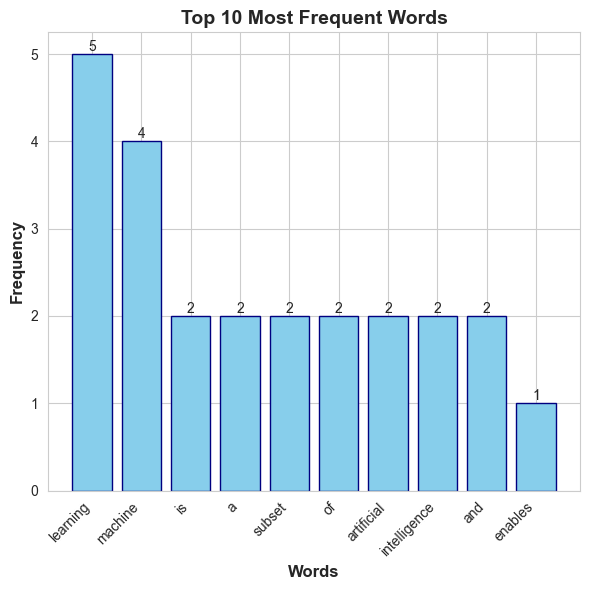

In [6]:
# Test the word frequency visualization
sample_text = """Machine learning is a subset of artificial intelligence. 
Machine learning enables systems to learn and improve from experience. 
Deep learning is a subset of machine learning. 
Artificial intelligence and machine learning are transforming technology."""
print(f"Input Text: {sample_text}\n")
freq_dict = word_frequency_visualization(sample_text, top_n=10)